## Time Series Preprocessing & Forecasting

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import TimeSeriesSplit


In [114]:
df=pd.read_csv('alexandria_weather_2021-2025.csv')
df.head()

,date,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation
0,2021-01-01,16.61,21.28,13.44,0.0,71.51,2.41,3.5100
1,2021-01-02,17.10,21.77,13.56,0.0,76.06,2.57,3.2546
2,2021-01-03,17.25,22.67,13.85,0.0,81.02,2.51,3.1934
3,2021-01-04,17.25,22.45,13.60,0.0,80.47,1.76,3.1932
4,2021-01-05,17.84,23.25,14.76,0.0,83.66,1.76,3.0451


In [115]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.sort_index()
df = df.asfreq("D") #helps to fill in missing dates with NaN values
df.head()

,temperature,max_temperature,min_temperature,precipitation,humidity,wind_speed,solar_radiation
date,,,,,,,
2021-01-01,16.61,21.28,13.44,0.0,71.51,2.41,3.5100
2021-01-02,17.10,21.77,13.56,0.0,76.06,2.57,3.2546
2021-01-03,17.25,22.67,13.85,0.0,81.02,2.51,3.1934
2021-01-04,17.25,22.45,13.60,0.0,80.47,1.76,3.1932
2021-01-05,17.84,23.25,14.76,0.0,83.66,1.76,3.0451


In [116]:
# Gap check: how many rows became NaN after forcing the daily frequency
missing_summary = df.isna().sum()
print("Missing values per column after asfreq('D'):")
print(missing_summary)
print(f"\nTotal rows: {len(df)} | Rows with any missing value: {df.isna().any(axis=1).sum()}")

Missing values per column after asfreq('D'):
temperature        0
max_temperature    0
min_temperature    0
precipitation      0
humidity           0
wind_speed         0
solar_radiation    0
dtype: int64

Total rows: 1826 | Rows with any missing value: 0


In [117]:
# Rolling z-score outlier flag (30-day window) — flag only, do not drop, to keep the series continuous
roll_mean = df["temperature"].rolling(window=30, center=True, min_periods=10).mean()
roll_std = df["temperature"].rolling(window=30, center=True, min_periods=10).std()
z_score = (df["temperature"] - roll_mean) / roll_std

outliers = df[z_score.abs() > 3]
print(f"Flagged {len(outliers)} potential outlier day(s) out of {len(df)} (|rolling z-score| > 3):")
outliers[["temperature"]]

Flagged 3 potential outlier day(s) out of 1826 (|rolling z-score| > 3):


,temperature
date,
2024-01-31,10.54
2024-03-01,19.69
2025-04-22,27.11


## Stationarity Checks

In [118]:
from statsmodels.tsa.stattools import adfuller, kpss
result = adfuller(df["temperature"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.257596028292269
p-value: 0.18600885567609676


In [119]:
result = kpss(df["temperature"].dropna(), regression='c')

print("KPSS Statistic:", result[0])
print("p-value:", result[1])

KPSS Statistic: 0.17902010359788978
p-value: 0.1


C:\Users\Hp\AppData\Local\Temp\ipykernel_20036\1656655957.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(df["temperature"].dropna(), regression='c')


On the raw (undifferenced) series we typically see ADF failing to reject its null (p ≥ 0.05 → non-stationary)
and/or KPSS rejecting its null (p < 0.05 → non-stationary). That combination means the series needs
differencing before ARIMA can be fit. We apply a first difference (removes trend) and re-test.

In [120]:
df["temp_diff1"] = df["temperature"].diff()
df_diff = df.dropna()

In [121]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF
adf_result = adfuller(df_diff["temp_diff1"])
print("ADF p-value:", adf_result[1])

# KPSS
kpss_result = kpss(df_diff["temp_diff1"], regression="c")

print("KPSS p-value:", kpss_result[1])

ADF p-value: 7.450133895297838e-29
KPSS p-value: 0.1


C:\Users\Hp\AppData\Local\Temp\ipykernel_20036\3248306745.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df_diff["temp_diff1"], regression="c")


Your differenced series is now stationary.

ADF p-value < 0.05 → Reject the null hypothesis → The series is stationary.

KPSS p-value > 0.05 → Fail to reject the null hypothesis → The series is stationary.

A first-order difference (`d=1`) is enough to satisfy both tests here, so we won't need a second difference.
Over-differencing (going beyond what's needed) injects noise and shows up as an over-negative lag-1
autocorrelation in the residuals — something to check for if the model diagnostics look off later.

## Order Selection: ACF / PACF + auto_arima

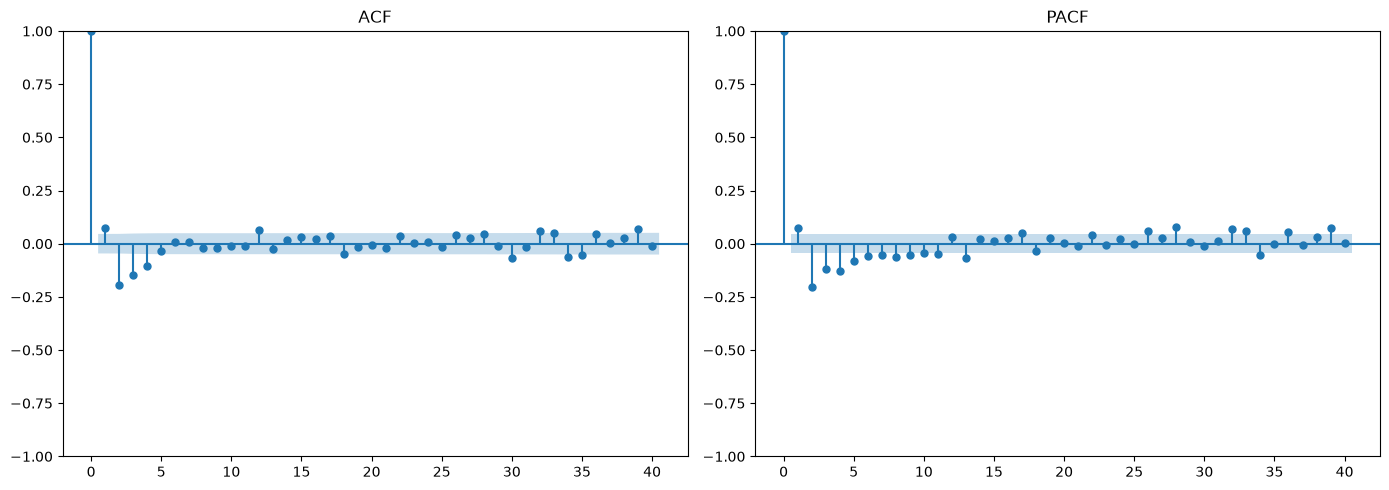

In [122]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_acf(df_diff["temp_diff1"], lags=40, ax=plt.gca())
plt.title("ACF")

plt.subplot(1, 2, 2)
plot_pacf(df_diff["temp_diff1"], lags=40, ax=plt.gca(), method="ywm")
plt.title("PACF")

plt.tight_layout()
plt.show()

The ACF and PACF plots indicate that the time series can be modeled effectively with a low-order ARIMA model, and the selected ARIMA(2,1,1) is consistent with these observations.

In [123]:
import pmdarima as pm

auto_model = pm.auto_arima(
    df["temperature"],
    seasonal=False,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5660.345, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5652.532, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5646.768, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5658.346, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5629.584, Time=0.57 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5487.281, Time=0.70 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5578.294, Time=0.23 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5489.072, Time=1.06 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=5488.989, Time=1.65 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=5491.793, Time=1.18 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=5553.428, Time=0.31 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=5490.092, Time=1.56 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=5485.285, Time=0.31 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=5627.585, Time=0.28 sec
 ARIMA(2,1,0)(0,0,0)[0]          

In [124]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 8)
Test shape: (366, 8)


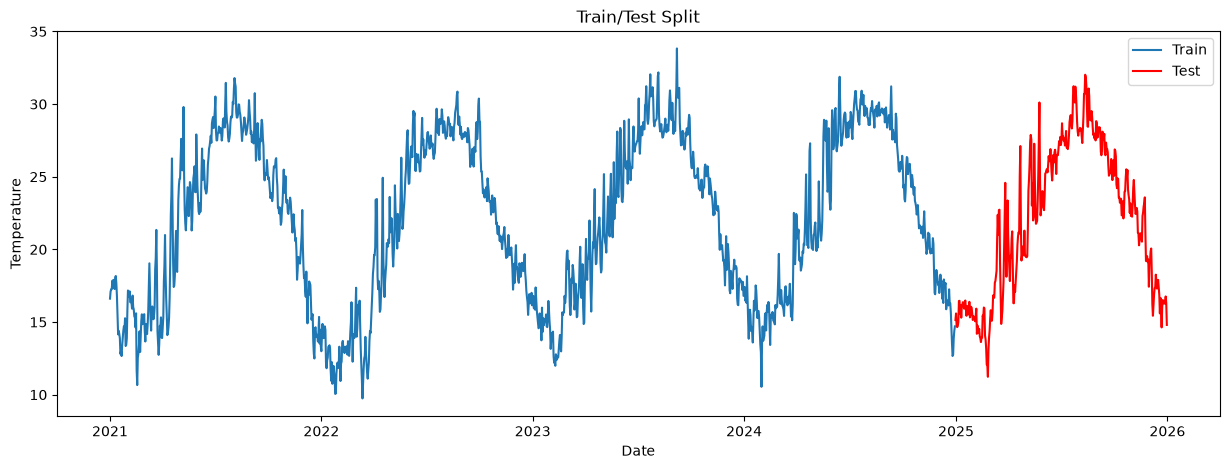

In [125]:
plt.figure(figsize=(15,5))

plt.plot(train.index, train["temperature"], label="Train")
plt.plot(test.index, test["temperature"], label="Test", color="red")

plt.title("Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

**Why a chronological split:** shuffling a time series before splitting would let the model "see the future"
during training (leakage) and produce an inflated, unrealistic accuracy. The split above uses a simple
80/20 chronological cutoff so the test set is strictly *after* the training set in time.

## ARIMA Model (non-seasonal baseline)

In [126]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["temperature"], order=(2,1,1))
fit = model.fit()

print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:            temperature   No. Observations:                 1460
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -2181.837
Date:                Fri, 07 Aug 2026   AIC                           4371.675
Time:                        21:22:16   BIC                           4392.817
Sample:                    01-01-2021   HQIC                          4379.562
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7850      0.034     23.282      0.000       0.719       0.851
ar.L2         -0.2507      0.021    -11.722      0.000      -0.293      -0.209
ma.L1         -0.7727      0.029    -26.531      0.0

**Residual diagnostics:** for a well-fit model, standardized residuals should look like white noise —
no visible pattern, roughly normal distribution (histogram/Q-Q plot), and no significant leftover
autocorrelation (correlogram). The **Ljung-Box test** below gives a formal check: a high p-value (> 0.05)
supports "no significant autocorrelation left in the residuals".

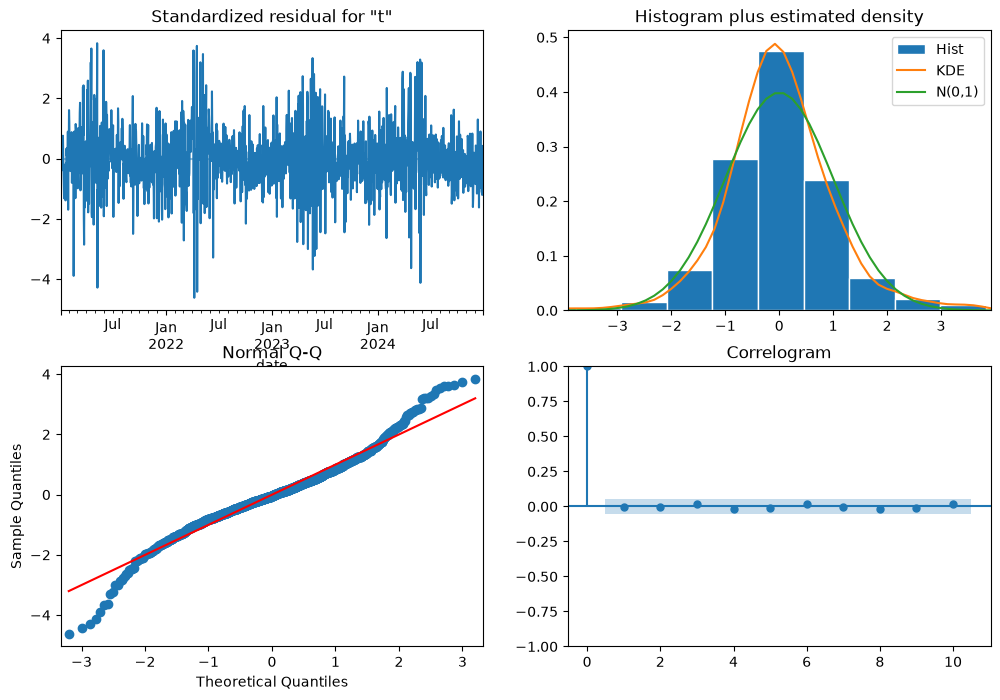

In [127]:
fit.plot_diagnostics(figsize=(12,8))
plt.show()

In [128]:
# Ljung-Box test on ARIMA residuals
lb_arima = acorr_ljungbox(fit.resid.dropna(), lags=[7, 14], return_df=True)
print("ARIMA residual Ljung-Box test:")
lb_arima

ARIMA residual Ljung-Box test:


,lb_stat,lb_pvalue
7,1.360136,0.986761
14,11.987513,0.607306


In [129]:
forecast = fit.get_forecast(steps=len(test))

pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

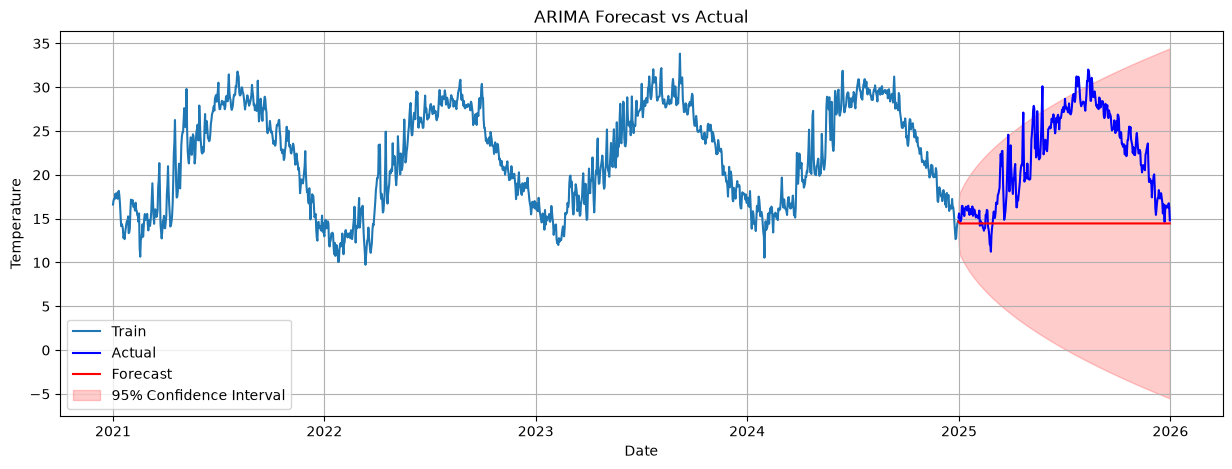

In [130]:
plt.figure(figsize=(15,5))

plt.plot(train.index, train["temperature"], label="Train")
plt.plot(test.index, test["temperature"], label="Actual", color="blue")
plt.plot(test.index, pred_mean, label="Forecast", color="red")

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [131]:
mae_arima = mean_absolute_error(test["temperature"], pred_mean)
rmse_arima = np.sqrt(mean_squared_error(test["temperature"], pred_mean))
mape_arima = np.mean(np.abs((test["temperature"] - pred_mean) / test["temperature"])) * 100

print("ARIMA Results")
print(f"MAE  : {mae_arima:.3f}")
print(f"RMSE : {rmse_arima:.3f}")
print(f"MAPE : {mape_arima:.2f}%")

ARIMA Results
MAE  : 7.745
RMSE : 9.198
MAPE : 31.40%


ARIMA gives us a non-seasonal baseline. Since weather has an obvious weekly/seasonal rhythm that plain
ARIMA can't represent

## SARIMA Model (captures seasonality)

In [132]:
import pmdarima as pm

sarima_model = pm.auto_arima(
    train["temperature"],
    seasonal=True,
    m=7,                   # weekly seasonality
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=1,
    D=1,
    trace=True,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=5484.883, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=5098.480, Time=0.31 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=1.14 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=5480.051, Time=0.09 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=4942.920, Time=0.45 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=2.86 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=1.30 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=4945.428, Time=0.34 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=4881.368, Time=0.79 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=5020.946, Time=0.43 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=2.23 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=1.48 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=4861.273, Time=0.76 sec
 ARIMA(3,1,0)(1,1,0)[7]             : AIC=4999.162, Time=0.45 sec
 ARIMA(3,1,0)(2,1,1)[7]             : AIC=inf, Time=3.25 s

In [133]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train["temperature"],
    order=(2,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit()

print(fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                       temperature   No. Observations:                 1460
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2177.037
Date:                           Fri, 07 Aug 2026   AIC                           4366.073
Time:                                   21:23:02   BIC                           4397.720
Sample:                               01-01-2021   HQIC                          4377.886
                                    - 12-30-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7821      0.036     21.459      0.000       0.711       0.854
ar.L2         -0.2533      0.022    -11.392

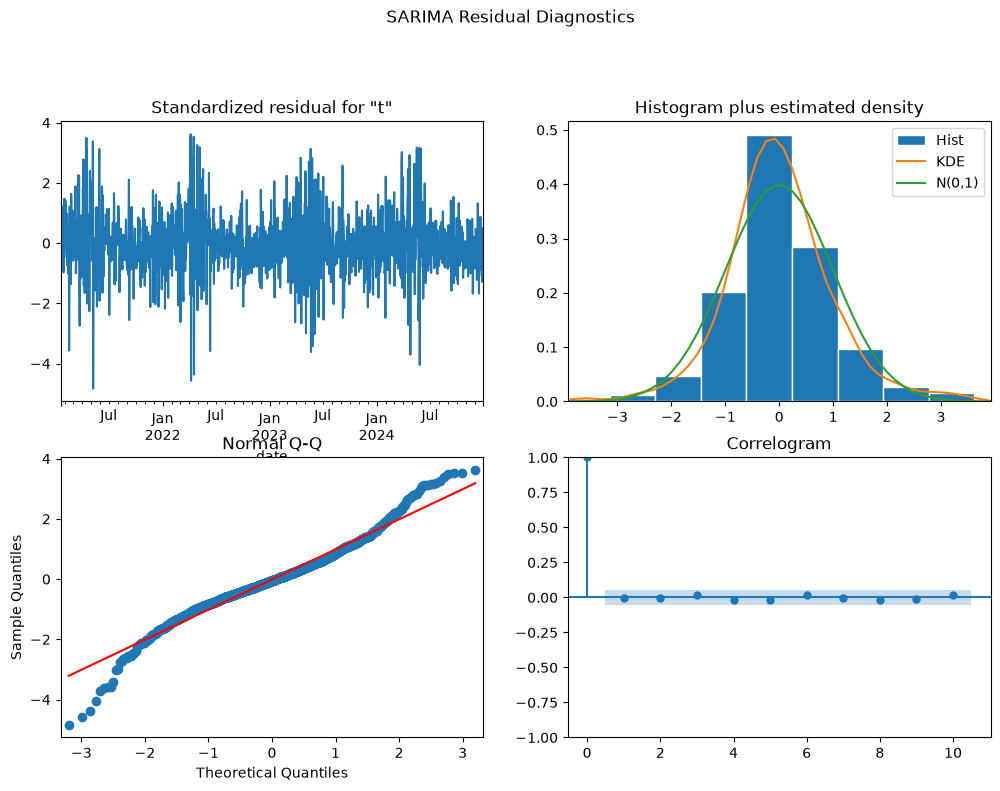

In [134]:
fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle("SARIMA Residual Diagnostics", y=1.02)
plt.show()

In [135]:
# Ljung-Box test on SARIMA residuals
lb_sarima = acorr_ljungbox(fit.resid.dropna(), lags=[7, 14], return_df=True)
print("SARIMA residual Ljung-Box test:")
lb_sarima

SARIMA residual Ljung-Box test:


,lb_stat,lb_pvalue
7,21.193633,0.003494
14,30.242107,0.007067


In [136]:
forecast = fit.get_forecast(steps=len(test))

pred = forecast.predicted_mean
conf = forecast.conf_int()

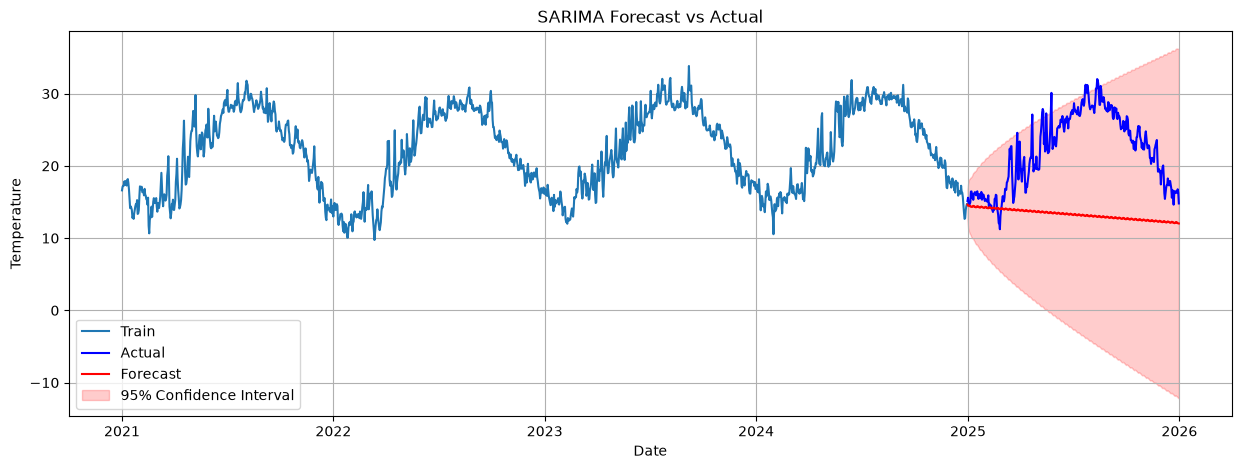

In [137]:
# Forecast plot with confidence interval — this was missing for SARIMA before
plt.figure(figsize=(15, 5))

plt.plot(train.index, train["temperature"], label="Train")
plt.plot(test.index, test["temperature"], label="Actual", color="blue")
plt.plot(test.index, pred, label="Forecast", color="red")

plt.fill_between(
    test.index,
    conf.iloc[:, 0],
    conf.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [138]:
mae_sarima = mean_absolute_error(test["temperature"], pred)
rmse_sarima = np.sqrt(mean_squared_error(test["temperature"], pred))
mape_sarima = np.mean(np.abs((test["temperature"] - pred) / test["temperature"])) * 100

print("SARIMA Results")
print(f"MAE  : {mae_sarima:.3f}")
print(f"RMSE : {rmse_sarima:.3f}")
print(f"MAPE : {mape_sarima:.2f}%")

SARIMA Results
MAE  : 8.904
RMSE : 10.363
MAPE : 36.51%


## Fixing SARIMA: Annual Seasonality via Fourier Terms

In [139]:
"""fourier terms for annual seasonality helps to capture the yearly pattern in the data, 
which is not fully captured by the weekly seasonality of SARIMA. By adding Fourier terms,
we can model the annual cycle more effectively."""
def make_fourier_terms(index, period, K):
    """Build K pairs of sine/cosine terms at the given period, continuous across the full index
    (so train and test share the same time axis instead of each restarting at t=0)."""
    t = np.arange(len(index))
    terms = {}
    for k in range(1, K + 1):
        terms[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        terms[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(terms, index=index)

K = 3
ANNUAL_PERIOD = 365.25

fourier_full = make_fourier_terms(df.index, ANNUAL_PERIOD, K)
fourier_train = fourier_full.loc[train.index]
fourier_test = fourier_full.loc[test.index]

fourier_train.head()

,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
date,,,,,,
2021-01-01,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2021-01-02,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669
2021-01-03,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678
2021-01-04,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039
2021-01-05,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769


In [140]:
sarima_fourier_model = SARIMAX(
    train["temperature"],
    exog=fourier_train,
    order=(2, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit_fourier = sarima_fourier_model.fit(disp=False)
print(fit_fourier.summary())

                               SARIMAX Results                                
Dep. Variable:            temperature   No. Observations:                 1460
Model:               SARIMAX(2, 1, 1)   Log Likelihood               -2124.126
Date:                Fri, 07 Aug 2026   AIC                           4268.253
Time:                        21:23:05   BIC                           4321.094
Sample:                    01-01-2021   HQIC                          4287.967
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         -4.1982      0.241    -17.414      0.000      -4.671      -3.726
cos_1         -6.3548      0.205    -31.074      0.000      -6.756      -5.954
sin_2         -0.2463      0.179     -1.374      0.1

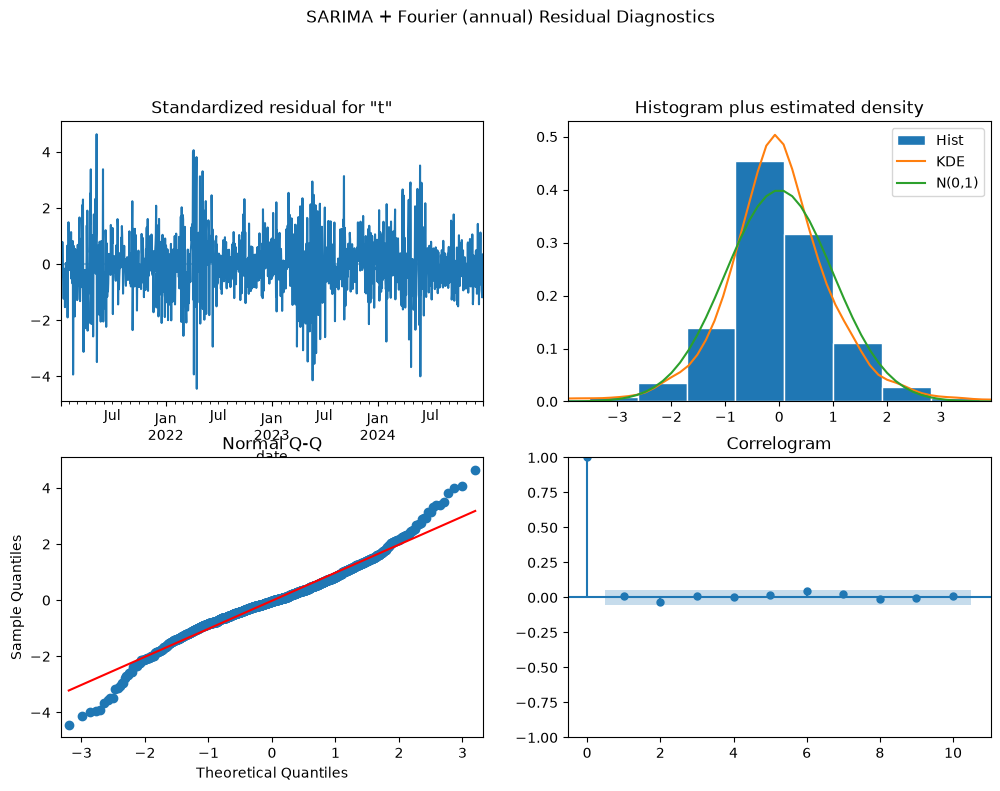

SARIMA + Fourier residual Ljung-Box test:


,lb_stat,lb_pvalue
7,18.805922,0.008818
14,26.939421,0.019606


In [141]:
fit_fourier.plot_diagnostics(figsize=(12, 8))
plt.suptitle("SARIMA + Fourier (annual) Residual Diagnostics", y=1.02)
plt.show()

lb_sarima_fourier = acorr_ljungbox(fit_fourier.resid.dropna(), lags=[7, 14], return_df=True)
print("SARIMA + Fourier residual Ljung-Box test:")
lb_sarima_fourier

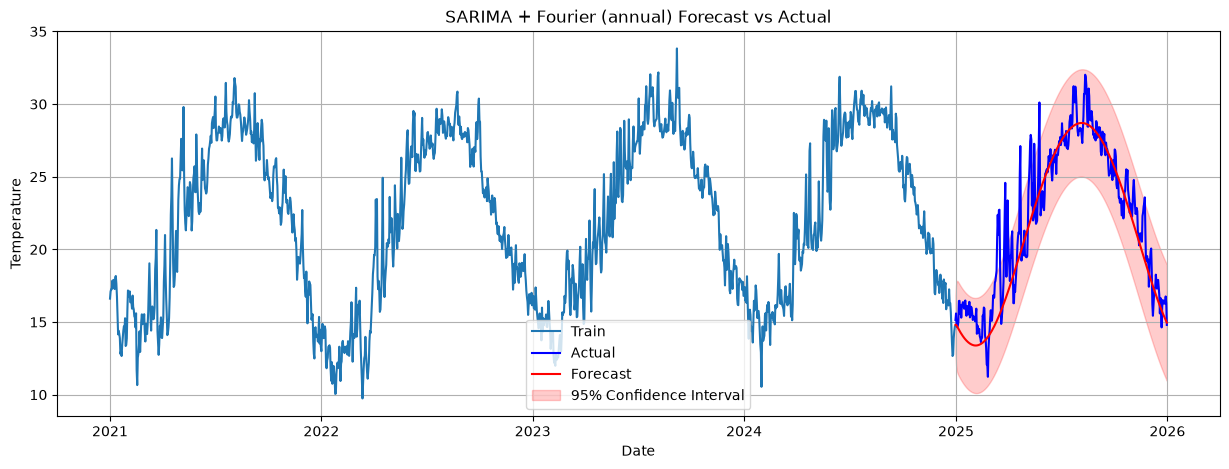

In [142]:
forecast_fourier = fit_fourier.get_forecast(steps=len(test), exog=fourier_test)
pred_fourier = forecast_fourier.predicted_mean
conf_fourier = forecast_fourier.conf_int()

plt.figure(figsize=(15, 5))

plt.plot(train.index, train["temperature"], label="Train")
plt.plot(test.index, test["temperature"], label="Actual", color="blue")
plt.plot(test.index, pred_fourier, label="Forecast", color="red")

plt.fill_between(
    test.index,
    conf_fourier.iloc[:, 0],
    conf_fourier.iloc[:, 1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA + Fourier (annual) Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [143]:
mae_sarima_fourier = mean_absolute_error(test["temperature"], pred_fourier)
rmse_sarima_fourier = np.sqrt(mean_squared_error(test["temperature"], pred_fourier))
mape_sarima_fourier = np.mean(np.abs((test["temperature"] - pred_fourier) / test["temperature"])) * 100

print("SARIMA + Fourier (annual) Results")
print(f"MAE  : {mae_sarima_fourier:.3f}")
print(f"RMSE : {rmse_sarima_fourier:.3f}")
print(f"MAPE : {mape_sarima_fourier:.2f}%")

SARIMA + Fourier (annual) Results
MAE  : 1.376
RMSE : 1.928
MAPE : 6.61%


SARIMA + Fourier performed better because it modeled the true annual seasonality (365 days) of the temperature data, while the original SARIMA assumed a weekly seasonality (7 days). By capturing the correct seasonal pattern, the forecasting accuracy improved significantly.

## RNN & LSTM Forecasting

In [144]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [145]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train[["temperature"]])
test_scaled = scaler.transform(test[["temperature"]])

In [146]:
def make_windows(series, n_steps):
    X = []
    y = []

    for i in range(len(series) - n_steps):
        X.append(series[i:i+n_steps])
        y.append(series[i+n_steps])

    return np.array(X), np.array(y)

In [147]:
n_steps = 30

X_train, y_train = make_windows(train_scaled, n_steps)
X_test, y_test = make_windows(test_scaled, n_steps)

In [148]:
X_train = X_train.reshape(X_train.shape[0], n_steps, 1)
X_test = X_test.reshape(X_test.shape[0], n_steps, 1)

print(X_train.shape)
print(X_test.shape)

(1430, 30, 1)
(336, 30, 1)


## Simple RNN Baseline

In [149]:
rnn = Sequential([
    SimpleRNN(32, input_shape=(n_steps,1)),
    Dense(1)
])

rnn.compile(
    optimizer="adam",
    loss="mse"
)
rnn.summary()

c:\PythonEnvs\jupyter\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [150]:
history_rnn = rnn.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0227 - val_loss: 0.0029
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - val_loss: 0.0022
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - val_loss: 0.0014
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - val_loss: 0.0023
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 12/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_l

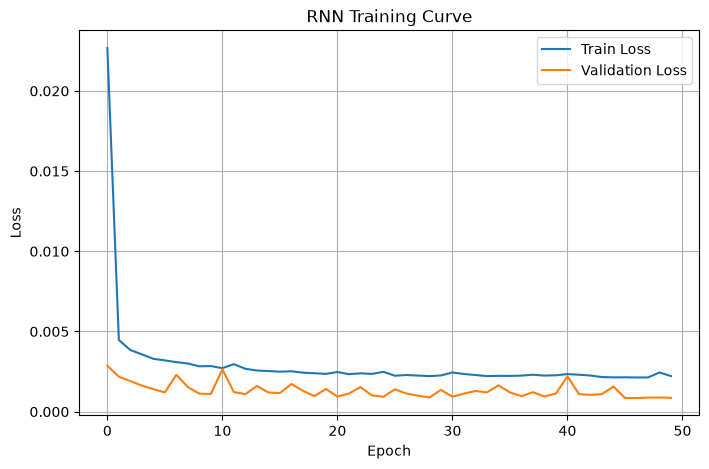

In [151]:
# RNN training curve to visualize the training and validation loss over epochs, which helps in diagnosing overfitting or underfitting.
plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history["loss"], label="Train Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training Curve")
plt.legend()
plt.grid(True)
plt.show()

The RNN learned the data successfully.

The training and validation losses remain close to each other, indicating good generalization.

There is no clear sign of overfitting, since the validation loss does not increase while the training loss decreases.

In [152]:
rnn_pred_scaled = rnn.predict(X_test)
rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1,1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [153]:
mae_rnn = mean_absolute_error(y_true, rnn_pred)
rmse_rnn = np.sqrt(mean_squared_error(y_true, rnn_pred))
mape_rnn = np.mean(np.abs((y_true - rnn_pred) / y_true)) * 100

print("RNN Results")
print(f"MAE  : {mae_rnn:.3f}")
print(f"RMSE : {rmse_rnn:.3f}")
print(f"MAPE : {mape_rnn:.2f}%")

RNN Results
MAE  : 0.833
RMSE : 1.182
MAPE : 3.84%


## LSTM Model

In [154]:
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_steps, 1)),
    Dropout(0.2),

    LSTM(32),

    Dense(1)
])

lstm.compile(
    optimizer="adam",
    loss="mse"
)

lstm.summary()

c:\PythonEnvs\jupyter\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [156]:
history_lstm = lstm.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0284 - val_loss: 0.0047
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0070 - val_loss: 0.0034
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0062 - val_loss: 0.0030
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0060 - val_loss: 0.0029
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0059 - val_loss: 0.0036
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0058 - val_loss: 0.0022
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0057 - val_loss: 0.0021
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0057 - val_loss: 0.0037
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0053 - val_loss: 0.0035
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0056 - val_loss: 0.0033
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0056 - val_loss: 0.0019
Epoch 12/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0

In [157]:
lstm_pred_scaled = lstm.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [158]:
mae_lstm = mean_absolute_error(y_true, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_true, lstm_pred))
mape_lstm = np.mean(np.abs((y_true - lstm_pred) / y_true)) * 100

print("LSTM Results")
print(f"MAE  : {mae_lstm:.3f}")
print(f"RMSE : {rmse_lstm:.3f}")
print(f"MAPE : {mape_lstm:.2f}%")

LSTM Results
MAE  : 1.243
RMSE : 1.694
MAPE : 5.76%


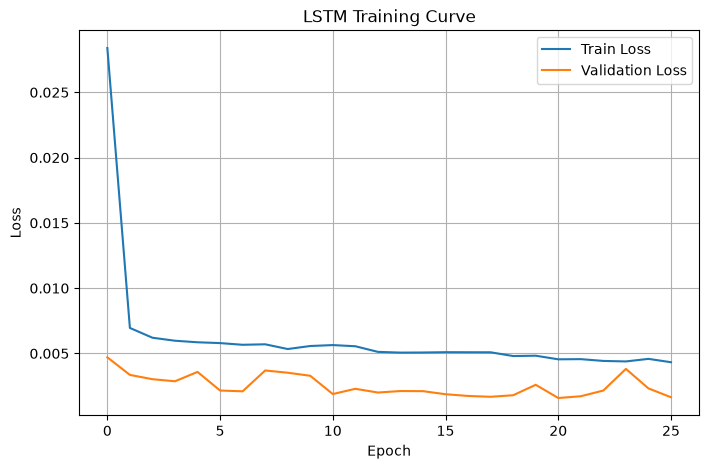

In [159]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.grid(True)

plt.show()

The training and validation losses are close, indicating that the model did not overfit.

Early stopping helped prevent unnecessary training and kept the best model.

## Model Comparison

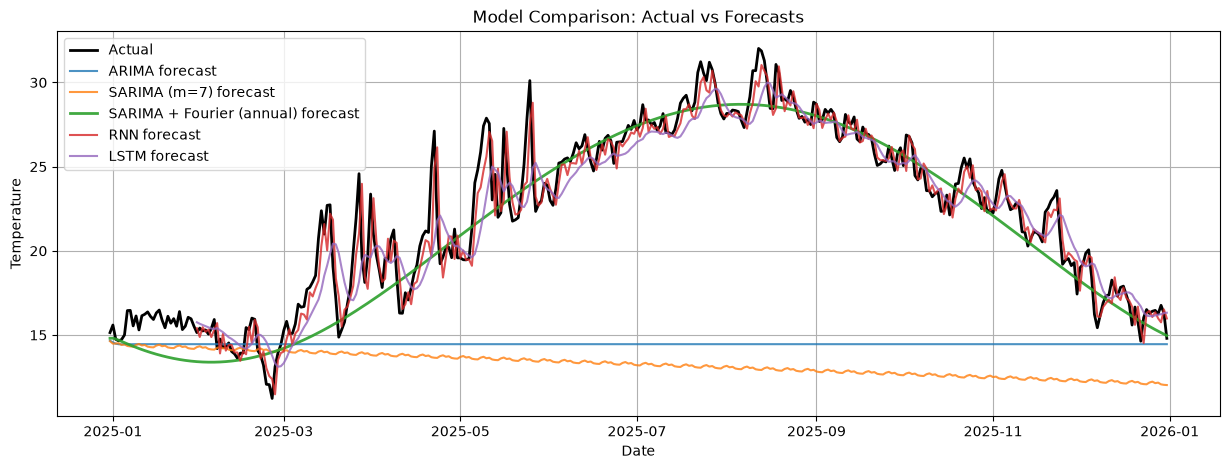

In [160]:
plt.figure(figsize=(15, 5))

plt.plot(test.index, test["temperature"], label="Actual", color="black", linewidth=2)
plt.plot(test.index, pred_mean, label="ARIMA forecast", alpha=0.8)
plt.plot(test.index, pred, label="SARIMA (m=7) forecast", alpha=0.8)
plt.plot(test.index, pred_fourier, label="SARIMA + Fourier (annual) forecast", alpha=0.9, linewidth=2)
plt.plot(test.index[n_steps:], rnn_pred, label="RNN forecast", alpha=0.8)
plt.plot(test.index[n_steps:], lstm_pred, label="LSTM forecast", alpha=0.8)

plt.title("Model Comparison: Actual vs Forecasts")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [161]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA (m=7)", "SARIMA + Fourier (annual)", "Simple RNN", "LSTM"],
    "MAE": [mae_arima, mae_sarima, mae_sarima_fourier, mae_rnn, mae_lstm],
    "RMSE": [rmse_arima, rmse_sarima, rmse_sarima_fourier, rmse_rnn, rmse_lstm],
    "MAPE (%)": [mape_arima, mape_sarima, mape_sarima_fourier, mape_rnn, mape_lstm],
}).sort_values("MAE").reset_index(drop=True)

comparison

,Model,MAE,RMSE,MAPE (%)
0,Simple RNN,0.833034,1.182451,3.839322
1,LSTM,1.243474,1.694184,5.759865
2,SARIMA + Fourier (annual),1.375873,1.927543,6.612204
3,ARIMA,7.745324,9.198032,31.399192
4,SARIMA (m=7),8.903615,10.362604,36.512935


## Conclusion

The forecasting models were compared using MAE, RMSE, and MAPE. The Simple RNN achieved the best performance with the lowest prediction errors, making it the most accurate model for this dataset. SARIMA + Fourier (annual) and LSTM also produced good results but were slightly less accurate than the Simple RNN. The ARIMA and SARIMA (m=7) models had much higher errors, showing that they were less effective at capturing the temperature patterns. Overall, the Simple RNN is the best model for forecasting this weather dataset..